<a href="https://colab.research.google.com/github/romainstead/knn_mnist/blob/main/sovr_plat_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорт библиотек


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Загрузка и обрезка датасета (60к изображений многовато)

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


x_train = x_train[:6000]
y_train = y_train[:6000]
x_test = x_test[:1000]
y_test = y_test[:1000]
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(6000, 28, 28) (6000,)
(1000, 28, 28) (1000,)


# Расчёт Евклидового расстояния и сама kNN

In [ ]:
def distance(x, y):
    return np.sqrt(np.sum(np.square(x-y)))

def kNN(x, k, data, label):
    distances = [distance(x,data[i]) for i in range(len(data))]
    idx = np.argpartition(distances, k - 1)
    clas, freq = np.unique(label[idx[:k]], return_counts=True)
    return clas[np.argmax(freq)]

# Зависимость accuracy от k

In [ ]:
# kNN(x_test[i], 5, x_train, y_train)
ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
accuracies = {}
for k in ks:
    true_counter = 0
    for i in range(len(x_test)):
        if kNN(x_test[i], k, x_train, y_train) == y_test[i]:
            true_counter += 1
    accuracies[k] = true_counter / len(y_test)
print(accuracies)

# {1: 0.904, 2: 0.9, 3: 0.913, 4: 0.913, 5: 0.916, 6: 0.913, 7: 0.914, 8: 0.913, 9: 0.909, 10: 0.906}

{1: 0.904, 2: 0.9, 3: 0.913, 4: 0.913, 5: 0.916, 6: 0.913, 7: 0.914, 8: 0.913, 9: 0.909, 10: 0.906}


# Confusion matrix для k = 5

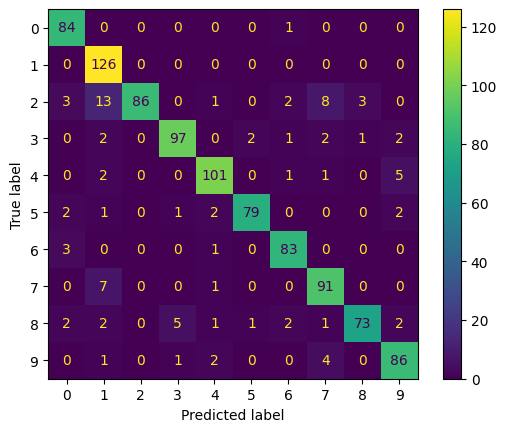

In [ ]:
y_true = y_test
y_pred = []
for i in range(len(x_test)):
    y_pred.append(kNN(x_test[i], k, x_train, y_train))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

# Проверка на своем рисунке

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image
k = 5
test_img = Image.open('/content/drive/MyDrive/knn_example.png').convert("1")
test_img_array = np.array(test_img)
print(kNN(test_img_array, k, x_train, y_train)) # правильный ответ - 3

3
